In [1]:
!pip install ultralytics -q

from ultralytics import YOLO
import matplotlib.pyplot as plt
print("✅ Setup Complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 940.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Setup Complete!


# Day 12: Instance Segmentation with YOLO11-seg

**New Concept Learned Today:**
- Moving from Bounding Box Detection → **Pixel-level Instance Segmentation**
- Understanding masks, contours, and area calculation
- Object property analysis (size, shape)

This is a big step up in computer vision capability.

In [2]:
# Load YOLO11 Segmentation model
model = YOLO("yolo11s-seg.pt")   # Segmentation version

print("✅ YOLO11 Segmentation Model Loaded!")

✅ YOLO11 Segmentation Model Loaded!



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 834.7ms
Speed: 16.2ms preprocess, 834.7ms inference, 47.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/segment/predict


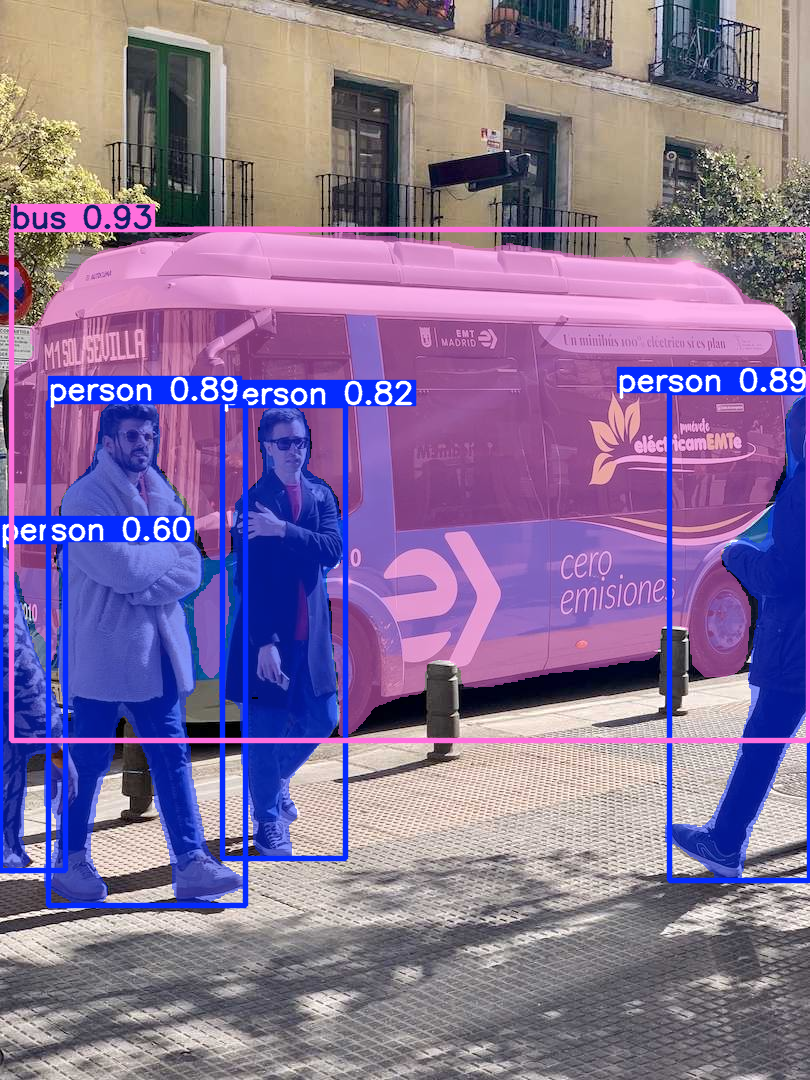

Number of objects detected: 5
Object 1 - Area: 92001 pixels
Object 2 - Area: 8454 pixels
Object 3 - Area: 19105 pixels
Object 4 - Area: 12781 pixels
Object 5 - Area: 3826 pixels


In [ ]:

results = model("https://ultralytics.com/images/bus.jpg", conf=0.3, save=True)

# Show result with masks
results[0].show()

# Advanced: Extract mask information
for result in results:
    if result.masks is not None:
        print(f"Number of objects detected: {len(result.masks)}")
        for i, mask in enumerate(result.masks.data):
            area = mask.sum().item()   # Approximate area in pixels
            print(f"Object {i+1} - Area: {area:.0f} pixels")